In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

## Часть 2.2 Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

In [ ]:
!dir

In [ ]:
!wget https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg -O sample_photo.jpg

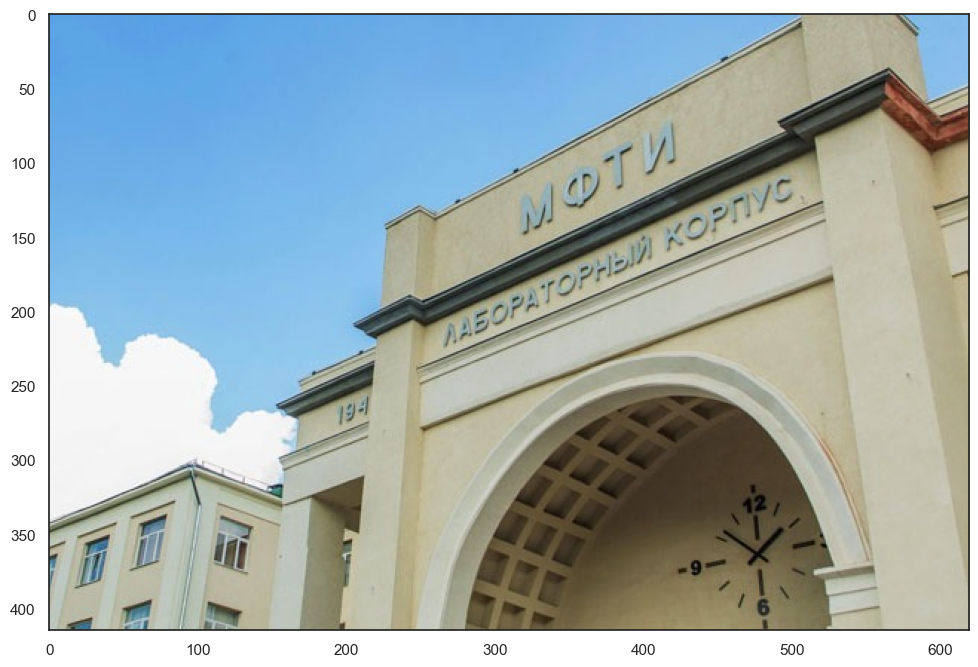

In [39]:
import cv2

sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [40]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F


In [41]:
conv_1 = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])  # A
conv_2 = np.array([[0, 1, 0], [0, -2, 0], [0, 1, 0]])  # Б
conv_3 = np.array([[0, 0, 0], [1, -2, 1], [0, 0, 0]])  # В
conv_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])  # Г
conv_5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])  # Д
conv_6 = np.array([[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]])  # E

In [42]:
conv = dict(А=conv_1, Б=conv_2, В=conv_3, Г=conv_4, Д=conv_5, Е=conv_6)

In [43]:
def image_cnn(image, conv):
    '''
    Функция преобразования изображения ядром свертки
    :param image: изображение
    :param conv: ядро
    :return: изображение
    '''
    global img_t, kernel, result
    RGB_img = image
    img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
    kernel = torch.tensor(conv).reshape(1, 1, 3, 3).type(torch.float32)
    kernel = kernel.repeat(3, 3, 1, 1)
    img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
    img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size
    result = F.conv2d(img_t, kernel)[0]
    return result.permute(1, 2, 0).numpy() / 256 / 3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79296875..1.0351562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76692706..0.81901044].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1679688..1.4140625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2005209..2.0546875].


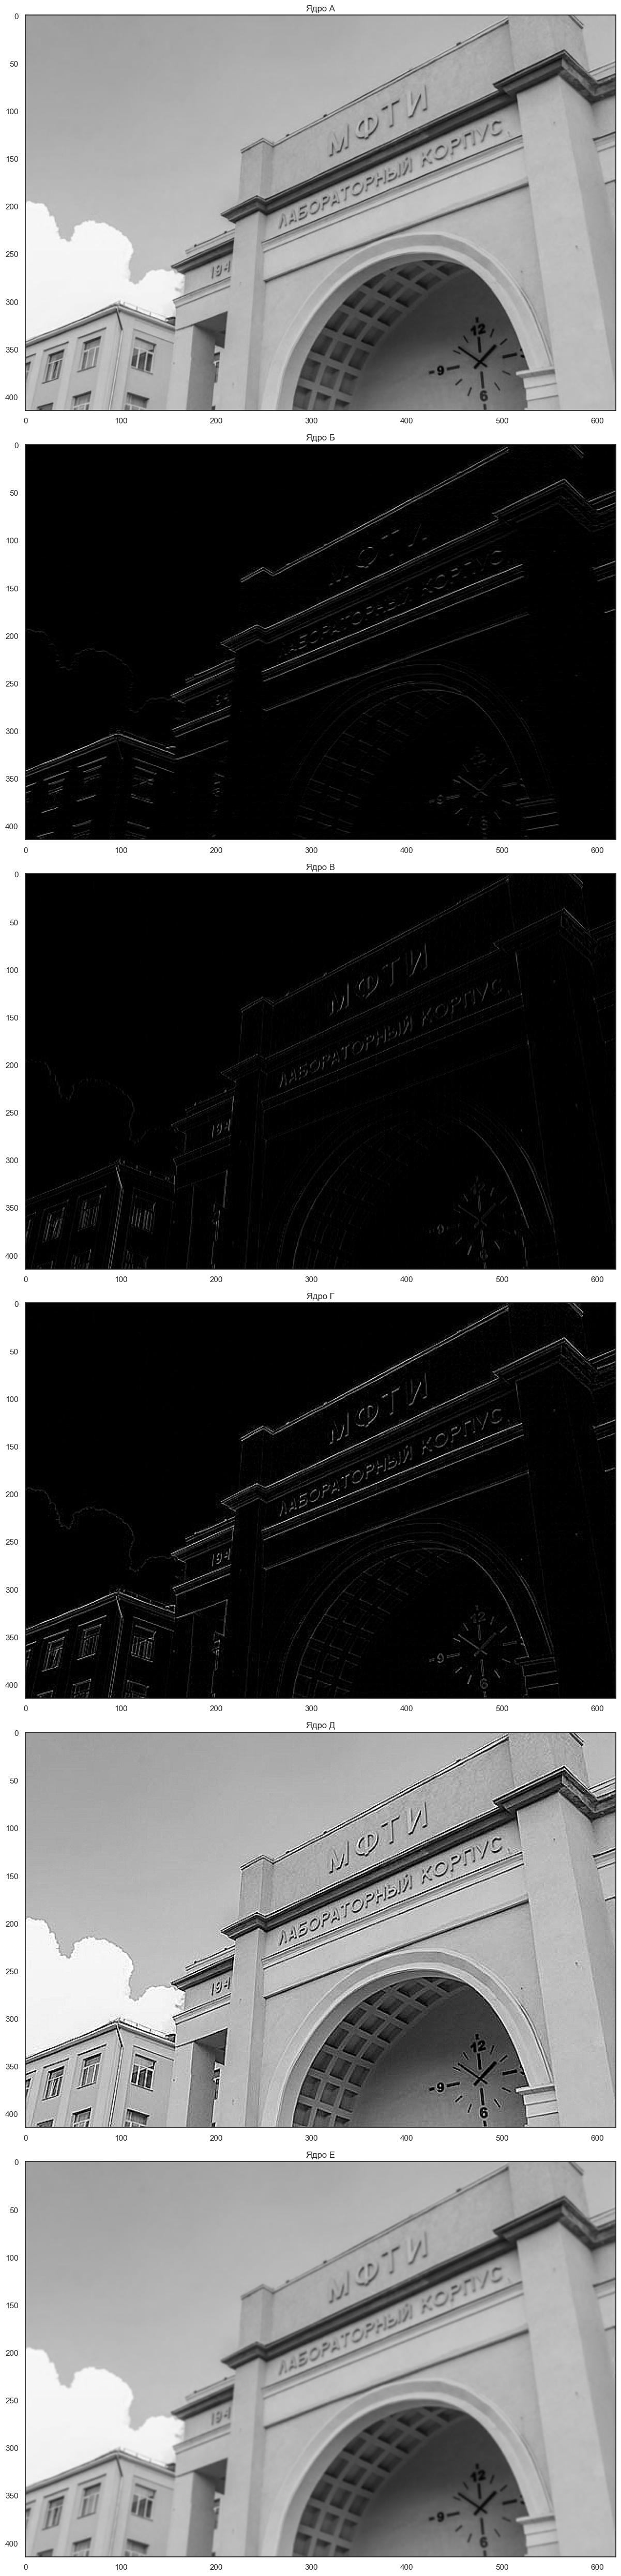

In [44]:
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(300, 50))

for ax, (key, value) in zip(axes.flatten(), conv.items()):

    ax.imshow(image_cnn(RGB_img,conv[key]))
    ax.set_title(f'Ядро {key}')

for ax in axes.flatten()[len(conv):]:
    ax.axis('off')

plt.tight_layout()

plt.show()

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

1) Размытие  **Е**
2) Увеличение резкости **Д**

3) Тождественное преобразование **А**

4) Выделение вертикальных границ **B**

5) Выделение горизонтальных границ **Б**

6) Выделение границ **Г**

**Ответ:**

### Задание 8. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.pool1 =  #YOUR CODE
        self.conv2 =  #YOUR CODE
        self.pool2 =  #YOUR CODE
        self.fc1 =  #YOUR CODE
        self.fc2 =  #YOUR CODE
        self.fc3 =  #YOUR CODE

    def forward(self, x):
        x =  #YOUR CODE. Apply layers created in __init__.
        ...
        return x

In [ ]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

### Задание 9. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [ ]:
#YOUR CODE

In [ ]:
lenet_accuracy = accuracy["valid"]

Сравним с предыдущем пунктом

In [ ]:
plt.figure(figsize=(16, 10))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), relu_accuracy, label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), leaky_relu_accuracy, label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), elu_accuracy, label="ELU activation", linewidth=2)
plt.plot(range(max_epochs), lenet_accuracy, label="LeNet", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 6**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:**